In [1]:
import torch

In [4]:
torch0d = torch.tensor(0)
torch1d = torch.tensor([1,2,3])
torch2d = torch.tensor([[1,2,3], [4,5,6]])
torch3d = torch.tensor([[[1,2,3], [4,5,6]], [[7,8,9], [10,11,12]]])
print(torch0d)
print(torch1d)
print(torch2d)
print(torch3d)

tensor(0)
tensor([1, 2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])


In [7]:
print(torch0d.dtype)

torch.int64


In [8]:
print(torch1d.to(torch.float32))

tensor([1., 2., 3.])


In [9]:
torch2d.reshape([3,2])

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [10]:
torch2d.view(3,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [11]:
torch2d.T

tensor([[1, 4],
        [2, 5],
        [3, 6]])

In [12]:
print(torch2d @ torch2d.T)

tensor([[14, 32],
        [32, 77]])


## Seeing models as compute graph

In [3]:
import torch.nn.functional as F

In [5]:
y = torch.tensor([1.0])
x = torch.tensor([1.1])
w = torch.tensor([2.2])
b = torch.tensor([0.0])

z = x * w + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a,y)
loss

tensor(0.0852)

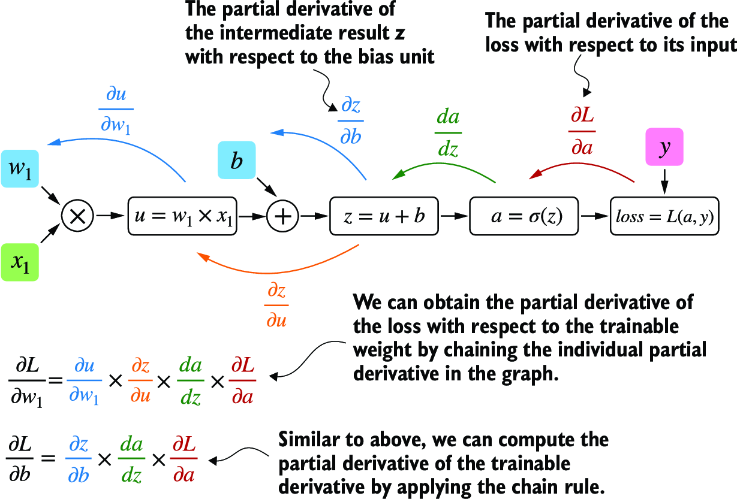

Computing loss gradients by applying the chain rule from the right to the left. Partial derivative of loss w.r.t to trainable weight and partial derivative of loss with respect to bias.

## Computing Gradients via autograd

In [9]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x = torch.tensor([1.1])
w = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x * w + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

grad_L_w = grad(loss, w, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)
print(grad_L_w)
print(grad_L_b)

loss.backward()
print(w.grad, "<= weight gradient")
print(b.grad, "<= bias gradient")

(tensor([-0.0898]),)
(tensor([-0.0817]),)
tensor([-0.0898]) <= weight gradient
tensor([-0.0817]) <= bias gradient


## Implementing Multilayer Neural Network

To implement a neural network in pytorch we can subclass `torch.nn.Module`. It gives the following features:
- Allows to encapsulate layers and operations
- Keep track of the model's parameters

> In deep learning initializing model weights with small random numbers is desired to break symmetery during training.
> The nodes otherwise perform same operations during backpropagation which would not allow it to learn complex mappins from inputs to outputs.

In [23]:
"Multilayer perceptron with two hidden networks"
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            # linear layer multiplies inputs with weights and adds
            # a bias referred to as feedforward or fully-connected 
            # layer.
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            #2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            #output layer
            torch.nn.Linear(20, num_outputs)
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

torch.manual_seed(123)
model = NeuralNetwork(50,3)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable parameters=> ", num_params)
print("layer 0 weights dim=>", model.layers[0].weight.shape)
print("layer 0 bias dim =>", model.layers[0].bias.shape)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)
trainable parameters=>  2213
layer 0 weights dim=> torch.Size([30, 50])
layer 0 bias dim => torch.Size([30])


In [22]:
X = torch.rand((1,50))
print(X)
out = model(X)
print(out)

tensor([[0.5131, 0.6978, 0.4537, 0.9035, 0.5088, 0.7786, 0.9455, 0.6622, 0.5138,
         0.4649, 0.0926, 0.1094, 0.6668, 0.5465, 0.6295, 0.0483, 0.7799, 0.4483,
         0.6947, 0.2243, 0.6045, 0.7574, 0.1262, 0.5446, 0.3269, 0.9105, 0.3953,
         0.2075, 0.1796, 0.4544, 0.7271, 0.6692, 0.9545, 0.8872, 0.5824, 0.6379,
         0.2836, 0.6754, 0.8838, 0.4898, 0.5963, 0.0890, 0.7804, 0.9223, 0.9605,
         0.7099, 0.3075, 0.5226, 0.2881, 0.2615]])


NotImplementedError: Module [NeuralNetwork] is missing the required "forward" function